<a href="https://colab.research.google.com/github/YuriFla94/Procesin/blob/main/Tarefa5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Hadamard Transform and CDMA Simulation
This notebook simulates a CDMA system with 3 users using Hadamard codes of length 8.

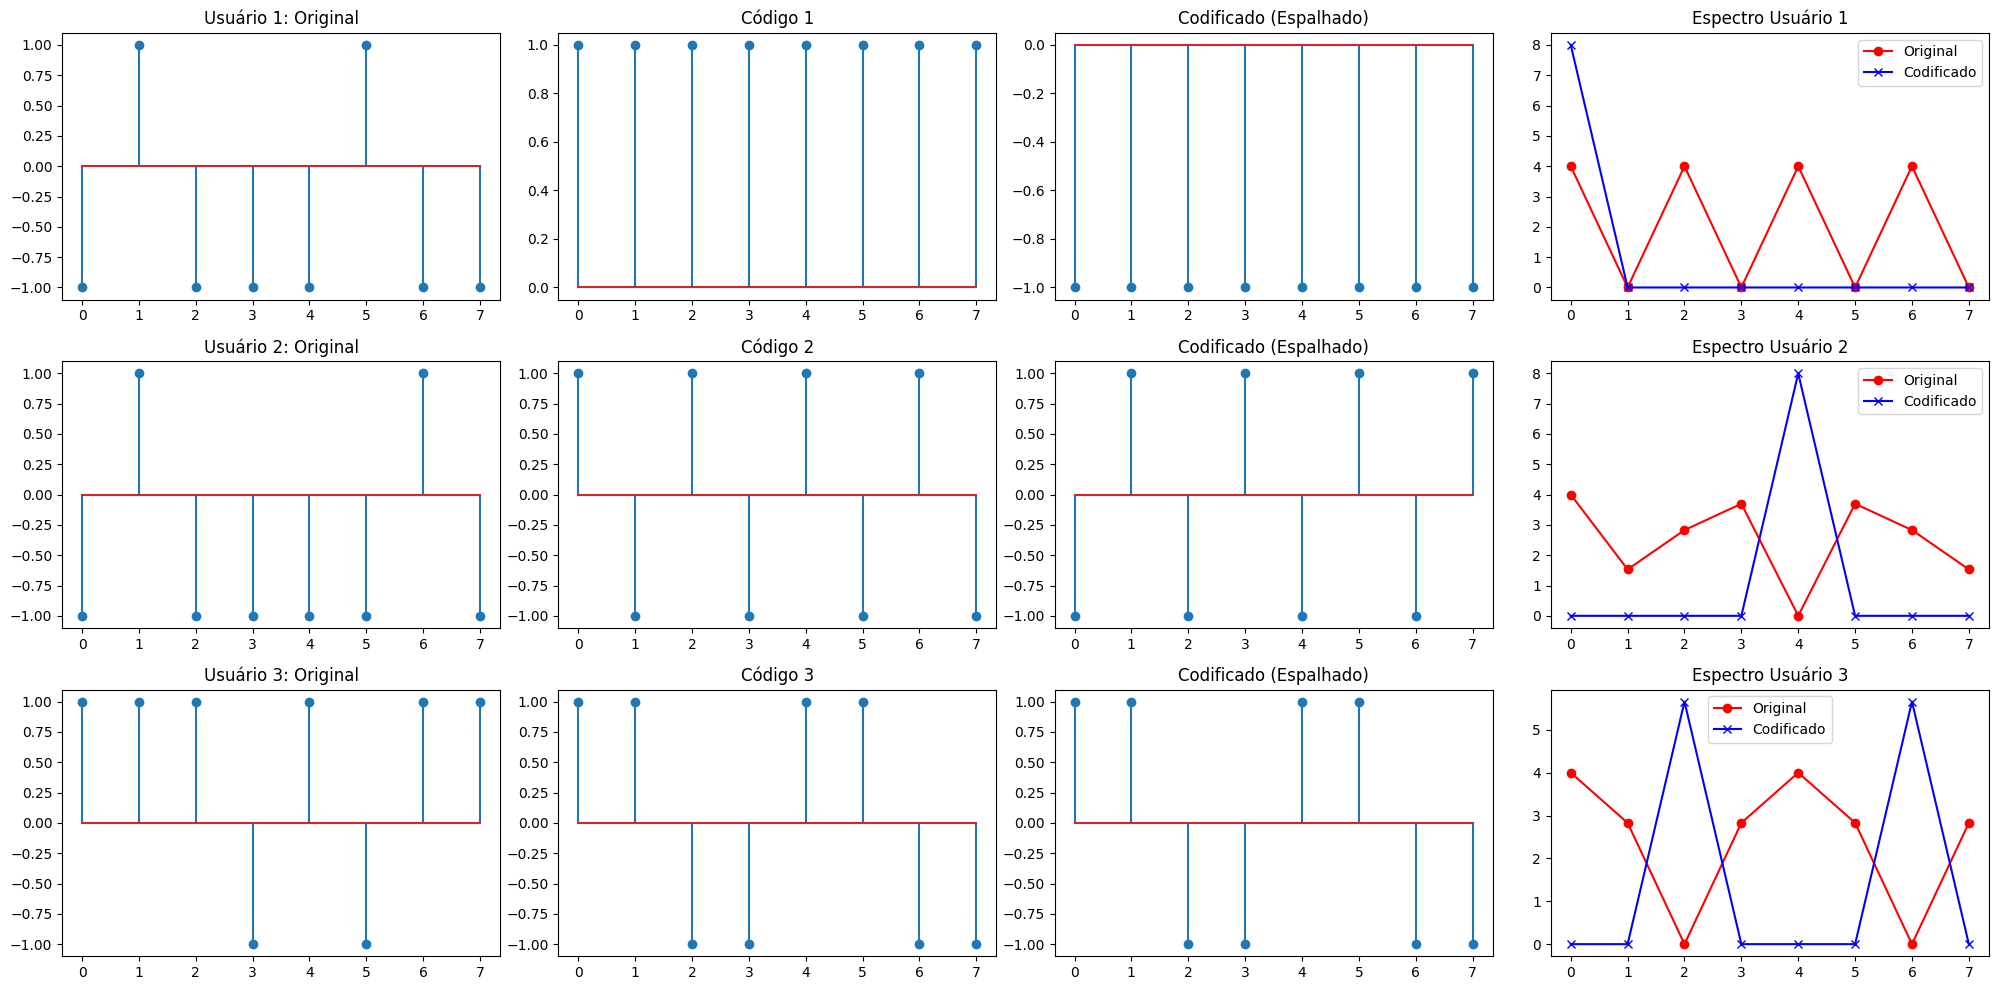

Comentário (a): A codificação CDMA (espalhamento espectral) distribui a energia do sinal por uma largura de banda muito maior, tornando o sinal codificado similar ao ruído no espectro.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard

# (a) Configuração dos Usuários e Codificação
N = 8
num_users = 3
np.random.seed(42)

# Mensagens m_k[n]
m = np.random.choice([-1, 1], size=(num_users, N))

# Matriz de Hadamard e códigos
H = hadamard(N)
codes = H[:num_users, :]

# Sinais codificados: x_k[n]
x = np.zeros((num_users, N))
for i in range(num_users):
    x[i] = m[i, 0] * codes[i]

# Plotagem
fig, axs = plt.subplots(num_users, 4, figsize=(20, 10))
for i in range(num_users):
    # Sinal Original
    axs[i, 0].stem(m[i])
    axs[i, 0].set_title(f'Usuário {i+1}: Original')
    # Código
    axs[i, 1].stem(codes[i])
    axs[i, 1].set_title(f'Código {i+1}')
    # Sinal Codificado
    axs[i, 2].stem(x[i])
    axs[i, 2].set_title(f'Codificado (Espalhado)')
    # Espectro (Magnitude da FFT)
    spec_orig = np.abs(np.fft.fft(m[i]))
    spec_cod = np.abs(np.fft.fft(x[i]))
    axs[i, 3].plot(spec_orig, 'r-o', label='Original')
    axs[i, 3].plot(spec_cod, 'b-x', label='Codificado')
    axs[i, 3].set_title(f'Espectro Usuário {i+1}')
    axs[i, 3].legend()

plt.tight_layout()
plt.show()

print('Comentário (a): A codificação CDMA (espalhamento espectral) distribui a energia do sinal por uma largura de banda muito maior, tornando o sinal codificado similar ao ruído no espectro.')

### (b) Channel Simulation with AWGN
We sum the signals and add noise: $y[n] = \sum x_k[n] + w[n]$.

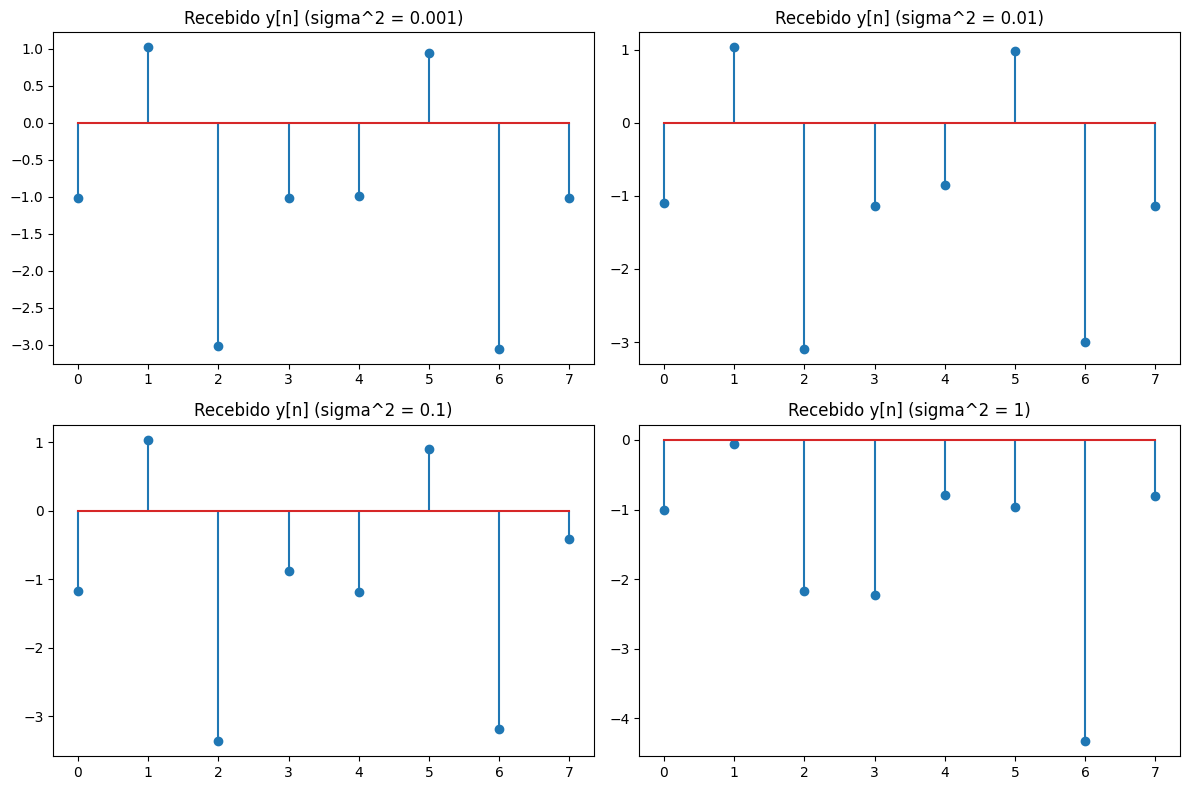

Comentário (b): Conforme sigma^2 aumenta, o ruído AWGN mascara os componentes do sinal no tempo. No espectro, isso se traduz em um aumento do patamar de ruído em todas as frequências.


In [ ]:
sigmas_sq = [1e-3, 1e-2, 1e-1, 1]
x_sum = np.sum(x, axis=0)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, s2 in enumerate(sigmas_sq):
    noise = np.random.normal(0, np.sqrt(s2), N)
    y = x_sum + noise
    axs[i].stem(y)
    axs[i].set_title(f'Recebido y[n] (sigma^2 = {s2})')

plt.tight_layout()
plt.show()

print('Comentário (b): Conforme sigma^2 aumenta, o ruído AWGN mascara os componentes do sinal no tempo. No espectro, isso se traduz em um aumento do patamar de ruído em todas as frequências.')

### (c) Recuperação Matemática
Usando notação vetorial, o sinal recebido é $\mathbf{y} = \sum_{i=1}^3 m_i \mathbf{c}_i + \mathbf{w}$.

Para recuperar o bit do usuário $k$:
$$\hat{m}_k = \text{sign}\left( \frac{1}{N} \mathbf{y} \cdot \mathbf{c}_k^T \right)$$

Expandindo $\mathbf{y}$:
$$\mathbf{y} \cdot \mathbf{c}_k^T = m_k (\mathbf{c}_k \cdot \mathbf{c}_k^T) + \sum_{i \neq k} m_i (\mathbf{c}_i \cdot \mathbf{c}_k^T) + \mathbf{w} \cdot \mathbf{c}_k^T$$

Como os códigos são ortogonais:
1. $\mathbf{c}_k \cdot \mathbf{c}_k^T = N$
2. $\mathbf{c}_i \cdot \mathbf{c}_k^T = 0$ para $i \neq k$

Logo, $\mathbf{y} \cdot \mathbf{c}_k^T = N m_k + \mathbf{w} \cdot \mathbf{c}_k^T$. O ruído impacta na estimativa se o termo $\mathbf{w} \cdot \mathbf{c}_k^T$ for forte o suficiente para inverter o sinal de $N m_k$.

### (e) Distorção no Código
Se $\hat{\mathbf{C}} = \mathbf{C} + \mathbf{W}_{code}$, e assumindo $\mathbf{w}=0$:
$$\text{Decisão} = (\sum m_i \mathbf{c}_i) \cdot (\mathbf{c}_k + \mathbf{w}_{code,k})^T$$
$$\text{Decisão} = N m_k + m_k (\mathbf{c}_k \cdot \mathbf{w}_{code,k}^T) + \sum_{i \neq k} m_i (\mathbf{c}_i \cdot \mathbf{w}_{code,k}^T)$$
A distorção causa interferência de multiusuário (MUI) e ruído multiplicativo.

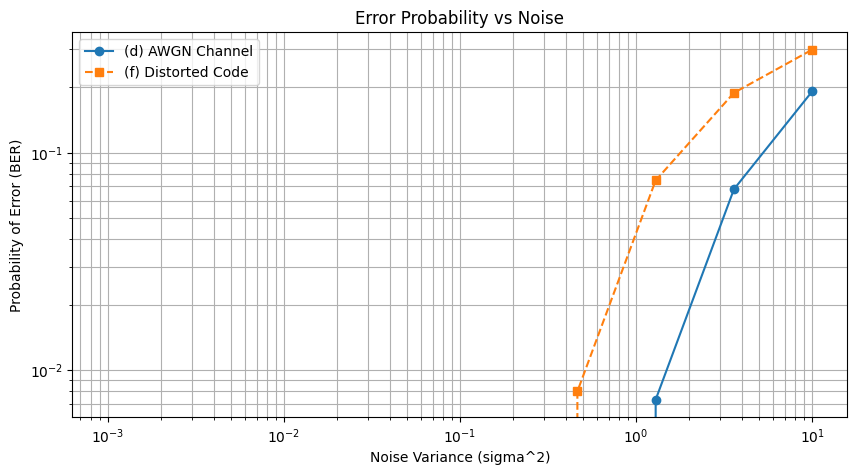

In [ ]:
def calculate_ber(sigma_vals, distorted_code=False):
    bers = []
    iterations = 1000
    for s2 in sigma_vals:
        errors = 0
        for _ in range(iterations):
            # Random bit for 3 users
            bits = np.random.choice([-1, 1], num_users)
            # Transmit
            tx_signal = np.zeros(N)
            for i in range(num_users):
                tx_signal += bits[i] * codes[i]

            if not distorted_code:
                # Item (d): Noise on channel
                rx_signal = tx_signal + np.random.normal(0, np.sqrt(s2), N)
                rx_codes = codes
            else:
                # Item (f): Noise on receiver code
                rx_signal = tx_signal
                rx_codes = codes + np.random.normal(0, np.sqrt(s2), (num_users, N))

            # Decode
            for i in range(num_users):
                estimate = np.sign(np.dot(rx_signal, rx_codes[i]))
                if estimate != bits[i]:
                    errors += 1
        bers.append(errors / (iterations * num_users))
    return bers

sigma_range = np.logspace(-3, 1, 10)
ber_d = calculate_ber(sigma_range, distorted_code=False)
ber_f = calculate_ber(sigma_range, distorted_code=True)

plt.figure(figsize=(10, 5))
plt.loglog(sigma_range, ber_d, 'o-', label='(d) AWGN Channel')
plt.loglog(sigma_range, ber_f, 's--', label='(f) Distorted Code')
plt.xlabel('Noise Variance (sigma^2)')
plt.ylabel('Probability of Error (BER)')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.title('Error Probability vs Noise')
plt.show()

```markdown
## 2. Transformada de Wavelet: Resumo e Aplicações

### O que é a Transformada de Wavelet?
A Transformada de Wavelet (WT) é uma ferramenta matemática que decompõe um sinal em diferentes componentes de frequência, mas, ao contrário da Transformada de Fourier, ela preserva a informação temporal. Isso é feito através do uso de **wavelets** (pequenas ondas) de duração limitada, que são transladadas e escalonadas (esticadas ou comprimidas).

*   **Resolução Variável:** Em altas frequências, a WT oferece boa resolução temporal (ajuda a localizar transições rápidas). Em baixas frequências, oferece boa resolução em frequência (ajuda a identificar componentes estáveis).
*   **Superação da STFT:** Diferente da Transformada de Fourier de Tempo Curto (STFT), a WT não utiliza uma janela de tamanho fixo, evitando o conflito de resolução do Princípio da Incerteza de Heisenberg de forma mais eficiente.

### Tipos Principais
1.  **Transformada de Wavelet Contínua (CWT):** Utilizada principalmente para análise e detecção de características em sinais.
2.  **Transformada de Wavelet Discreta (DWT):** Crucial para compressão e redução de ruído, operando através de bancos de filtros (filtros passa-baixa e passa-alta).

### Aplicações Práticas
*   **Compressão de Imagens e Vídeos:** O padrão **JPEG 2000** utiliza wavelets para compressão com perdas e sem perdas, permitindo reconstruções progressivas de alta qualidade.
*   **Redução de Ruído (Denoising):** Muito eficaz na remoção de ruído de sinais biomédicos (como ECG e EEG) e áudio, pois consegue separar o ruído das transições rápidas do sinal original.
*   **Geofísica e Sismologia:** Análise de abalos sísmicos e exploração de petróleo, onde é necessário identificar camadas geológicas a partir de ecos sonoros.
*   **Engenharia Biomédica:** Detecção de picos R em eletrocardiogramas e análise de variações na frequência cardíaca.
*   **Finanças:** Análise de séries temporais do mercado de ações para identificar tendências em diferentes escalas temporais.
```

## 3. Análise de Sinais Não Estacionários com Wavelets

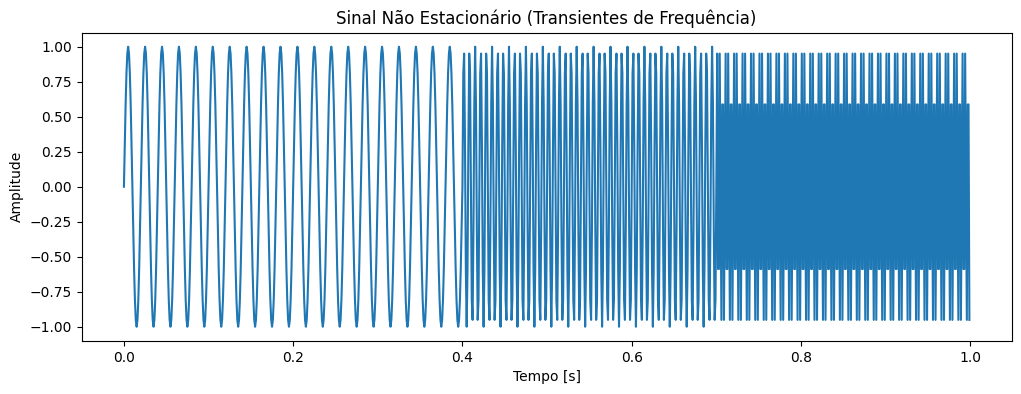

Comentário (a): O sinal possui três componentes de frequência distintas que ocorrem em janelas temporais diferentes (0-0.4s, 0.4-0.7s, 0.7-1.0s).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# (a) Geração do sinal não estacionário
fs = 1000
t = np.linspace(0, 1, fs, endpoint=False)

# Sinal composto por diferentes frequências em tempos distintos
s1 = np.sin(2 * np.pi * 50 * t[:400])   # 50Hz
s2 = np.sin(2 * np.pi * 150 * t[400:700]) # 150Hz
s3 = np.sin(2 * np.pi * 300 * t[700:])  # 300Hz
signal = np.concatenate([s1, s2, s3])

plt.figure(figsize=(12, 4))
plt.plot(t, signal)
plt.title('Sinal Não Estacionário (Transientes de Frequência)')
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude')
plt.show()

print('Comentário (a): O sinal possui três componentes de frequência distintas que ocorrem em janelas temporais diferentes (0-0.4s, 0.4-0.7s, 0.7-1.0s).')

Filtros de Análise:
Lo_D (Passa-baixa): [0.0, 0.03782845550726404, -0.023849465019556843, -0.11062440441843718, 0.37740285561283066, 0.8526986790088938, 0.37740285561283066, -0.11062440441843718, -0.023849465019556843, 0.03782845550726404]
Hi_D (Passa-alta): [-0.0, -0.06453888262869706, 0.04068941760916406, 0.41809227322161724, -0.7884856164055829, 0.41809227322161724, 0.04068941760916406, -0.06453888262869706, -0.0, 0.0]

Filtros de Síntese:
Lo_R (Passa-baixa): [0.0, -0.06453888262869706, -0.04068941760916406, 0.41809227322161724, 0.7884856164055829, 0.41809227322161724, -0.04068941760916406, -0.06453888262869706, 0.0, 0.0]
Hi_R (Passa-alta): [0.0, -0.03782845550726404, -0.023849465019556843, 0.11062440441843718, 0.37740285561283066, -0.8526986790088938, 0.37740285561283066, 0.11062440441843718, -0.023849465019556843, -0.03782845550726404]


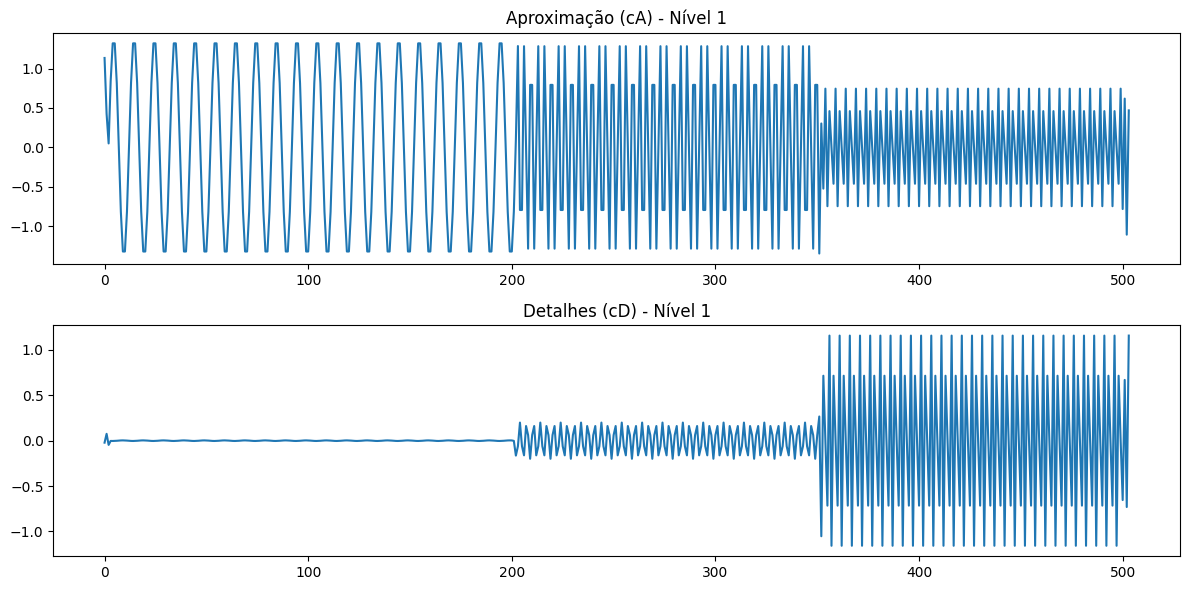

In [ ]:
# (b) Decomposição com Wavelet 7-9 (bior4.4)
wavelet = pywt.Wavelet('bior4.4')

# Coeficientes dos filtros
print("Filtros de Análise:")
print("Lo_D (Passa-baixa):", wavelet.dec_lo)
print("Hi_D (Passa-alta):", wavelet.dec_hi)

print("\nFiltros de Síntese:")
print("Lo_R (Passa-baixa):", wavelet.rec_lo)
print("Hi_R (Passa-alta):", wavelet.rec_hi)

# Uma decomposição simples de 1 nível
cA, cD = pywt.dwt(signal, wavelet)

plt.figure(figsize=(12, 6))
plt.subplot(2,1,1); plt.plot(cA); plt.title('Aproximação (cA) - Nível 1')
plt.subplot(2,1,2); plt.plot(cD); plt.title('Detalhes (cD) - Nível 1')
plt.tight_layout(); plt.show()

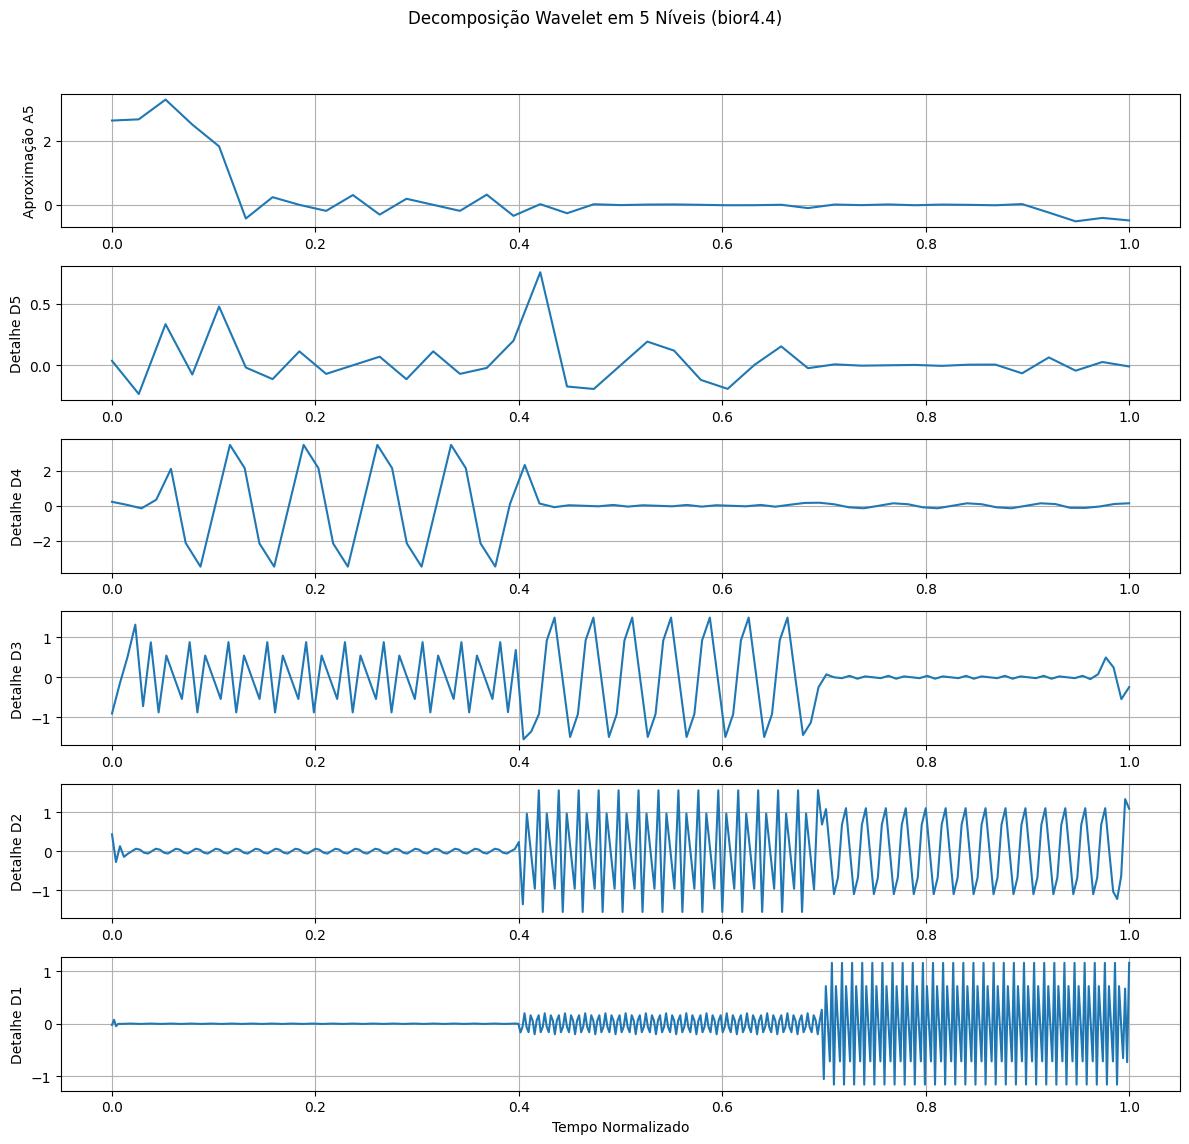

Comentário (c): A decomposição em múltiplos níveis permite identificar onde ocorrem as variações de alta frequência (detalhes D1 e D2 mostram os transientes de 150Hz e 300Hz), enquanto os níveis mais baixos de detalhe e a aproximação capturam a estrutura de baixa frequência do sinal.


In [ ]:
# (c) Transformada de Wavelet de 5 estágios
levels = 5
coeffs = pywt.wavedec(signal, 'bior4.4', level=levels)

fig, axes = plt.subplots(levels + 1, 1, figsize=(12, 12), sharex=False)

# Plotagem normalizando o eixo temporal (escala de 0 a 1)
for i, c in enumerate(coeffs):
    ax = axes[i]
    label = f'Aproximação A{levels}' if i == 0 else f'Detalhe D{levels - i + 1}'
    # Normalização do tempo para comparação
    t_norm = np.linspace(0, 1, len(c))
    ax.plot(t_norm, c)
    ax.set_ylabel(label)
    ax.grid(True)

axes[-1].set_xlabel('Tempo Normalizado')
plt.suptitle('Decomposição Wavelet em 5 Níveis (bior4.4)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print('Comentário (c): A decomposição em múltiplos níveis permite identificar onde ocorrem as variações de alta frequência (detalhes D1 e D2 mostram os transientes de 150Hz e 300Hz), enquanto os níveis mais baixos de detalhe e a aproximação capturam a estrutura de baixa frequência do sinal.')

### Detailed Analysis and Wavelet Decomposition

#### (a) Signal Explanation
The signal generated is **non-stationary** because its statistical properties (specifically its frequency content) change over time. It consists of three distinct segments:
1. **0.0 to 0.4 seconds:** A low-frequency sine wave at **50 Hz**.
2. **0.4 to 0.7 seconds:** A medium-frequency sine wave at **150 Hz**.
3. **0.7 to 1.0 seconds:** A high-frequency sine wave at **300 Hz**.

Traditional Fourier Analysis would show these three peaks but lose the information of *when* they occur. The Wavelet Transform allows us to see both the frequency components and their temporal location.

#### (b) Filter Coefficients for bior4.4
The `bior4.4` (Biorthogonal 7-9) wavelet is commonly used in image compression (like JPEG 2000). Unlike orthogonal wavelets, it uses different filters for analysis (decomposition) and synthesis (reconstruction), allowing for linear phase properties.

In [1]:
import pywt
import numpy as np

# Defining the wavelet
wavelet = pywt.Wavelet('bior4.4')

print("--- Analysis Filters (Decomposition) ---")
print(f"Low-pass (Lo_D): {wavelet.dec_lo}")
print(f"High-pass (Hi_D): {wavelet.dec_hi}")

print("\n--- Synthesis Filters (Reconstruction) ---")
print(f"Low-pass (Lo_R): {wavelet.rec_lo}")
print(f"High-pass (Hi_R): {wavelet.rec_hi}")

--- Analysis Filters (Decomposition) ---
Low-pass (Lo_D): [0.0, 0.03782845550726404, -0.023849465019556843, -0.11062440441843718, 0.37740285561283066, 0.8526986790088938, 0.37740285561283066, -0.11062440441843718, -0.023849465019556843, 0.03782845550726404]
High-pass (Hi_D): [-0.0, -0.06453888262869706, 0.04068941760916406, 0.41809227322161724, -0.7884856164055829, 0.41809227322161724, 0.04068941760916406, -0.06453888262869706, -0.0, 0.0]

--- Synthesis Filters (Reconstruction) ---
Low-pass (Lo_R): [0.0, -0.06453888262869706, -0.04068941760916406, 0.41809227322161724, 0.7884856164055829, 0.41809227322161724, -0.04068941760916406, -0.06453888262869706, 0.0, 0.0]
High-pass (Hi_R): [0.0, -0.03782845550726404, -0.023849465019556843, 0.11062440441843718, 0.37740285561283066, -0.8526986790088938, 0.37740285561283066, 0.11062440441843718, -0.023849465019556843, -0.03782845550726404]


#### (c) 5-Stage Wavelet Decomposition
We decompose the signal into one approximation (A5) and five levels of details (D1-D5).
- **D1, D2:** Capture the highest frequencies (the 300Hz and 150Hz transients).
- **A5:** Captures the slowest moving components of the signal.

By normalizing the x-axis to the range [0, 1], we can visually align the transients in the sub-bands with the original signal's timeline.

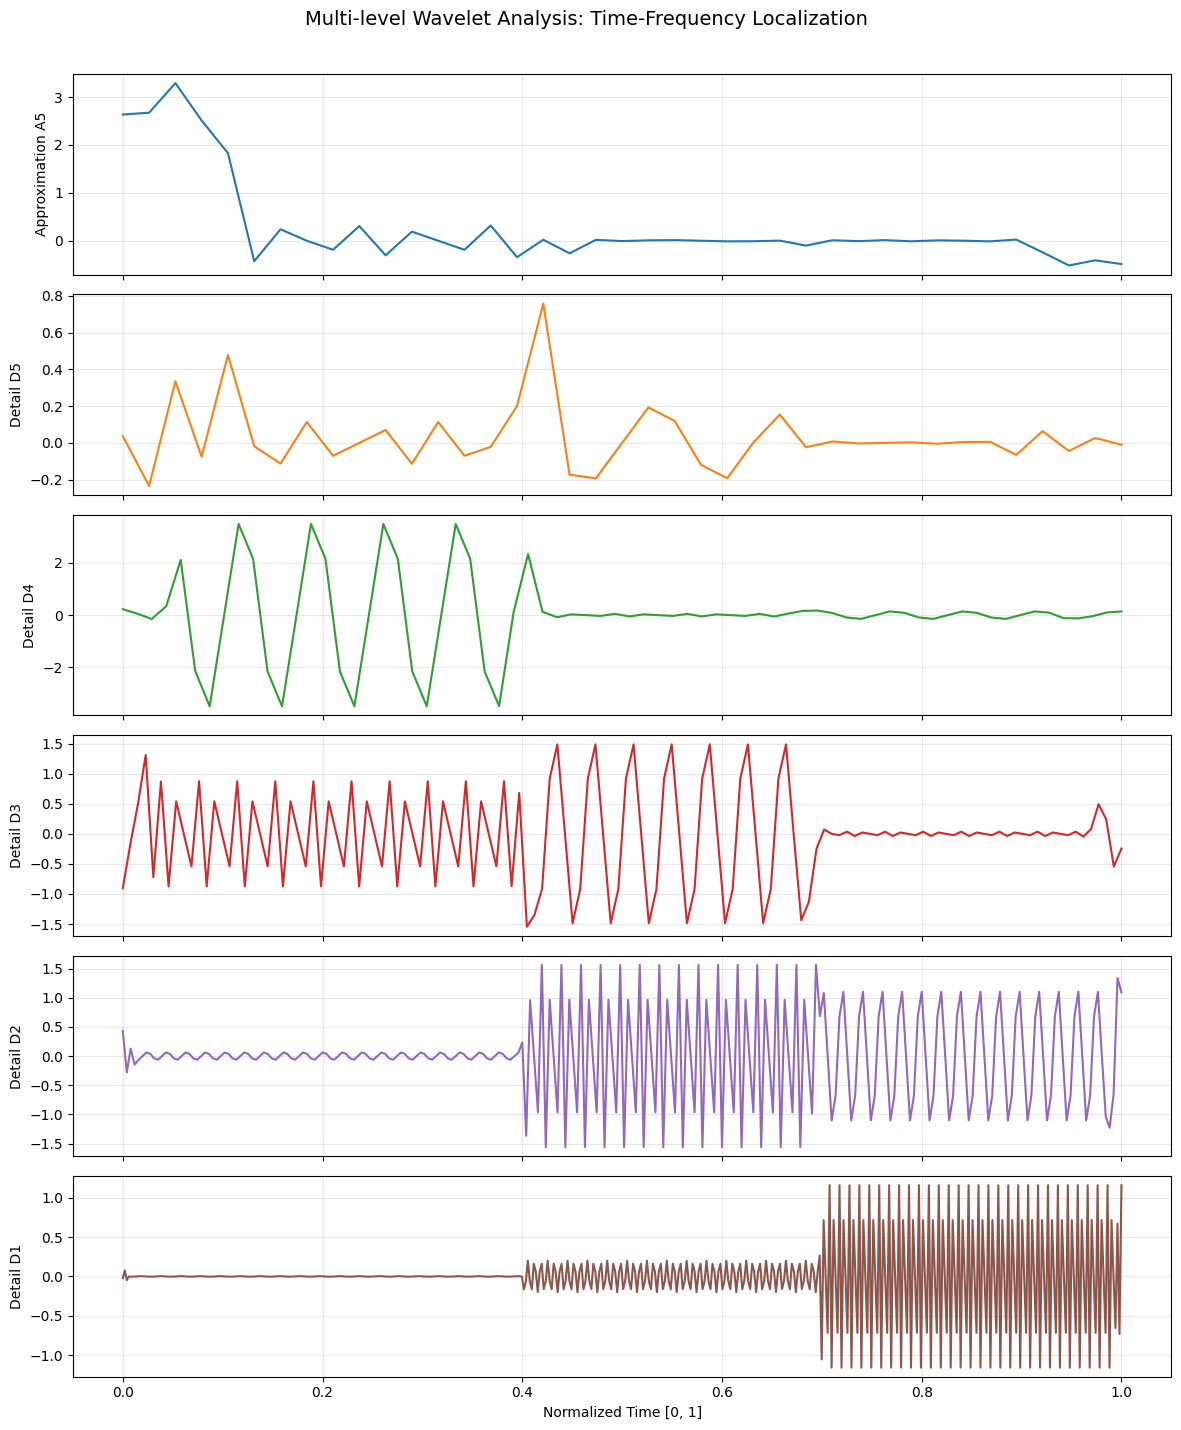

Result Analysis: Note how D1 and D2 show high activity where the 300Hz signal starts (t=0.7) and the 150Hz transitions, while the lower frequency (50Hz) is clearly preserved in the Approximation A5.


In [3]:
import matplotlib.pyplot as plt
import pywt
import numpy as np

# Re-generating the non-stationary signal to ensure it's defined
fs = 1000
t = np.linspace(0, 1, fs, endpoint=False)
s1 = np.sin(2 * np.pi * 50 * t[:400])
s2 = np.sin(2 * np.pi * 150 * t[400:700])
s3 = np.sin(2 * np.pi * 300 * t[700:])
signal = np.concatenate([s1, s2, s3])

# (c) 5-level decomposition
levels = 5
coeffs = pywt.wavedec(signal, 'bior4.4', level=levels)

fig, axes = plt.subplots(levels + 1, 1, figsize=(12, 15), sharex=False)

for i, c in enumerate(coeffs):
    ax = axes[i]
    # Label: coeffs[0] is approximation, rest are details
    label = f'Approximation A{levels}' if i == 0 else f'Detail D{levels - i + 1}'

    # Time normalization for comparison
    t_norm = np.linspace(0, 1, len(c))
    ax.plot(t_norm, c, color='C'+str(i))
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
    if i < levels:
        ax.set_xticklabels([])

axes[-1].set_xlabel('Normalized Time [0, 1]')
plt.suptitle('Multi-level Wavelet Analysis: Time-Frequency Localization', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

print("Result Analysis: Note how D1 and D2 show high activity where the 300Hz signal starts (t=0.7) and the 150Hz transitions, while the lower frequency (50Hz) is clearly preserved in the Approximation A5.")

## 4. Denoising Sinais com Wavelets (leleccum.mat)

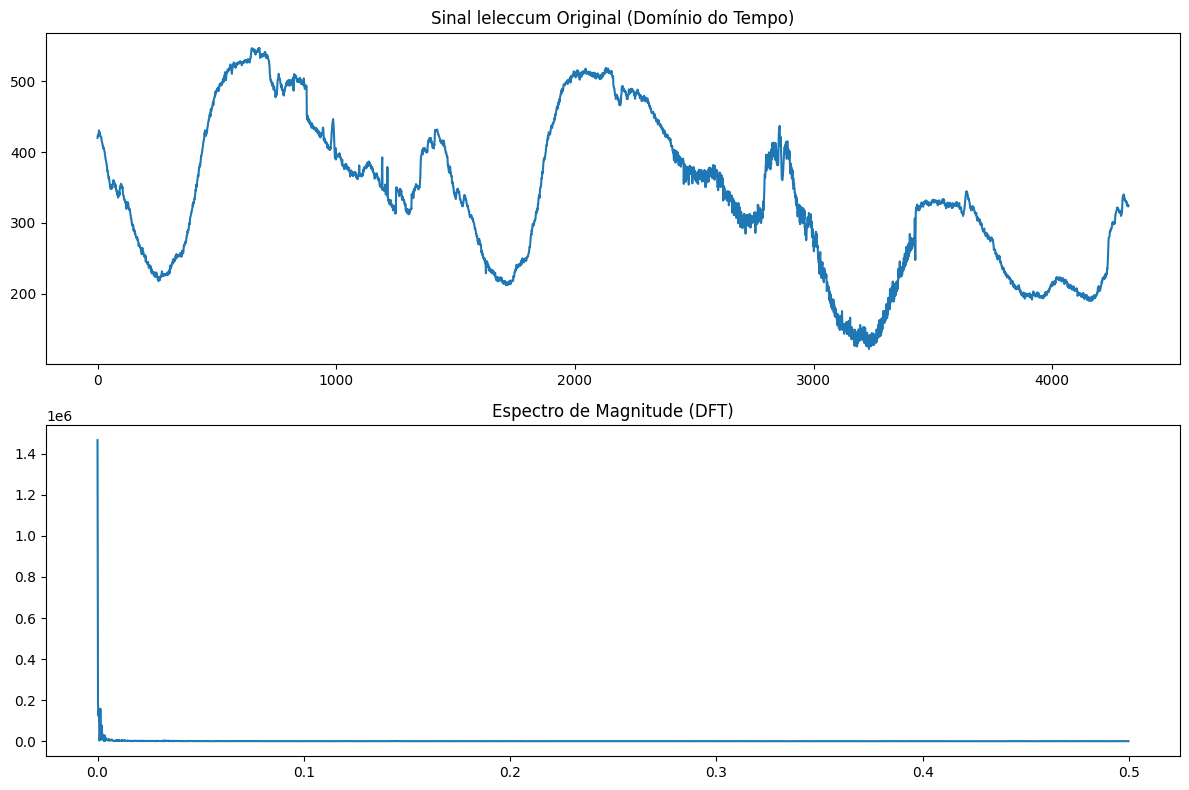

Comentário (a): O sinal apresenta uma estrutura oscilatória com componentes de ruído sobrepostos visíveis tanto no tempo quanto no espectro de alta frequência.


In [ ]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import pywt

# (a) Carregamento e Visualização
mat_data = scipy.io.loadmat('/content/leleccum.mat')
# 'leleccum' is typically a 1D signal in these MAT files
sig = mat_data['leleccum'].flatten()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(sig)
ax1.set_title('Sinal leleccum Original (Domínio do Tempo)')

spec = np.abs(np.fft.fft(sig))
freqs = np.fft.fftfreq(len(sig))
ax2.plot(freqs[:len(sig)//2], spec[:len(sig)//2])
ax2.set_title('Espectro de Magnitude (DFT)')
plt.tight_layout()
plt.show()

print('Comentário (a): O sinal apresenta uma estrutura oscilatória com componentes de ruído sobrepostos visíveis tanto no tempo quanto no espectro de alta frequência.')

In [4]:
# (b) Wavelet Daubechies 4 (db4)
db4 = pywt.Wavelet('db4')
print("Filtros de Análise (Ancillary):", db4.dec_lo, db4.dec_hi)
print("Filtros de Síntese (Ancillary):", db4.rec_lo, db4.rec_hi)

Filtros de Análise (Ancillary): [-0.010597401785069032, 0.0328830116668852, 0.030841381835560764, -0.18703481171909309, -0.027983769416859854, 0.6308807679298589, 0.7148465705529157, 0.2303778133088965] [-0.2303778133088965, 0.7148465705529157, -0.6308807679298589, -0.027983769416859854, 0.18703481171909309, 0.030841381835560764, -0.0328830116668852, -0.010597401785069032]
Filtros de Síntese (Ancillary): [0.2303778133088965, 0.7148465705529157, 0.6308807679298589, -0.027983769416859854, -0.18703481171909309, 0.030841381835560764, 0.0328830116668852, -0.010597401785069032] [-0.010597401785069032, -0.0328830116668852, 0.030841381835560764, 0.18703481171909309, -0.027983769416859854, -0.6308807679298589, 0.7148465705529157, -0.2303778133088965]


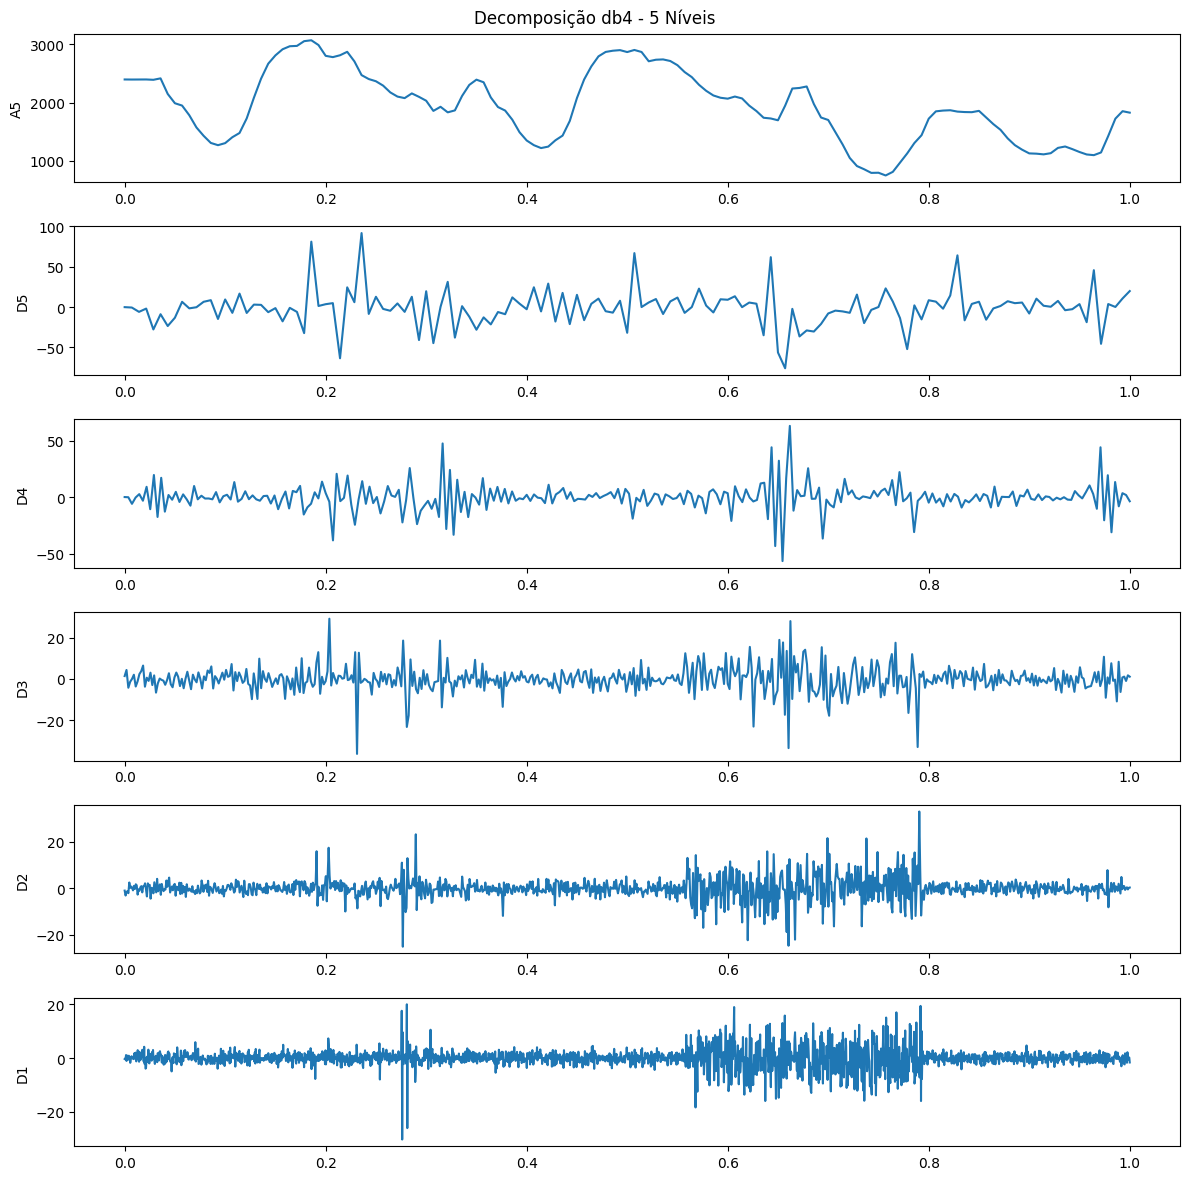

In [ ]:
# (c) Decomposição de 5 estágios
levels = 5
coeffs = pywt.wavedec(sig, 'db4', level=levels)

fig, axes = plt.subplots(levels + 1, 1, figsize=(12, 12))
for i, c in enumerate(coeffs):
    t_norm = np.linspace(0, 1, len(c))
    label = f'A{levels}' if i == 0 else f'D{levels-i+1}'
    axes[i].plot(t_norm, c)
    axes[i].set_ylabel(label)
plt.suptitle('Decomposição db4 - 5 Níveis')
plt.tight_layout()
plt.show()

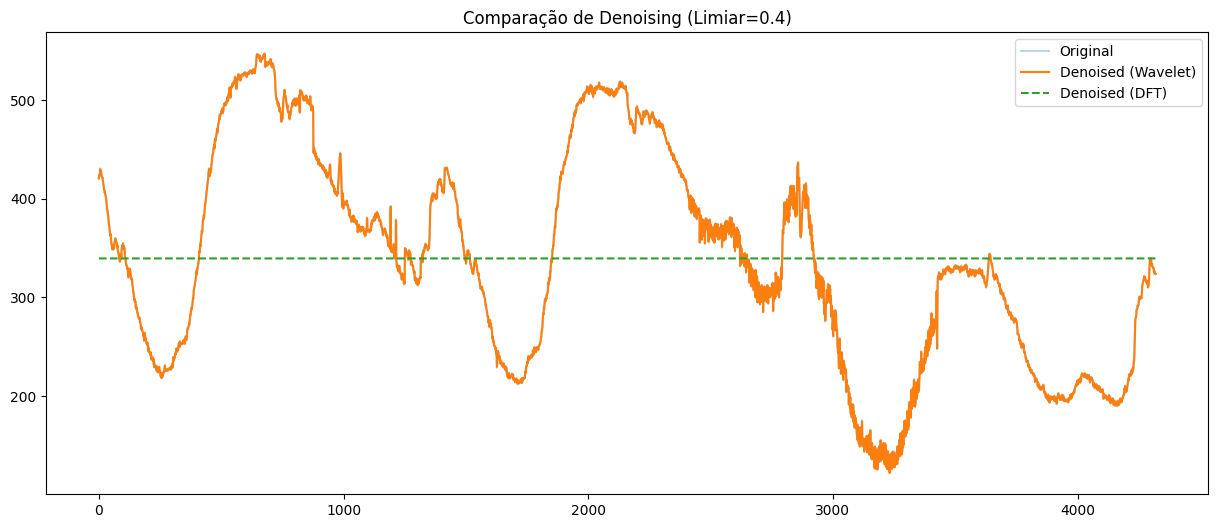

Comentário (d/e): O denoising por wavelet costuma preservar melhor as transições locais do sinal comparado ao corte abrupto na DFT, que pode causar oscilações de Gibbs.


In [ ]:
# (d) Denoising via Wavelet Thresholding
threshold = 0.4 # Exemplo de limiar inicial
coeffs_thresh = [pywt.threshold(c, threshold, mode='soft') if i > 0 else c for i, c in enumerate(coeffs)]
sig_denoised_wt = pywt.waverec(coeffs_thresh, 'db4')

# (e) Denoising via DFT Thresholding
sig_fft = np.fft.fft(sig)
# Aplicar limiar na magnitude da FFT
sig_fft_thresh = sig_fft * (np.abs(sig_fft) > (threshold * np.max(np.abs(sig_fft))))
sig_denoised_dft = np.fft.ifft(sig_fft_thresh).real

plt.figure(figsize=(15, 6))
plt.plot(sig, alpha=0.3, label='Original')
plt.plot(sig_denoised_wt, label='Denoised (Wavelet)')
plt.plot(sig_denoised_dft, label='Denoised (DFT)', linestyle='--')
plt.title(f'Comparação de Denoising (Limiar={threshold})')
plt.legend()
plt.show()

print('Comentário (d/e): O denoising por wavelet costuma preservar melhor as transições locais do sinal comparado ao corte abrupto na DFT, que pode causar oscilações de Gibbs.')